# 5. Análisis de Desigualdades y Justicia Ambiental


El objetivo es cruzar los niveles de contaminación obtenidos en el WP6 con los indicadores socioeconómicos de Liverpool. Debemos identificar si existe una correlación entre las zonas más privadas (pobres) y la peor calidad del aire, y evaluar la exposición de infraestructuras críticas como escuelas y hospitales.

## Objetivos
1. **Integración del IMD**: Vincular el Index of Multiple Deprivation (Índice de Privación Múltiple) de 2025 a cada LSOA del mapa de polución.

2. **Mapeo de Puntos de Interés (POI)**: Localizar en el mapa escuelas, hospitales y residencias de ancianos (datos de OSM obtenidos en el WP3).

3. **Análisis de Correlación**: Realizar un análisis estadístico (ej. correlación de Pearson o Spearman) entre los deciles de pobreza y los niveles de 
P
M
2.5
.

4. **Identificación de "Hotspots de Desigualdad**: Localizar barrios que cumplan la "doble carga": alta privación socioeconómica y alta contaminación.

5. **Evaluación de Escuelas**: Determinar cuántos centros educativos superan los límites anuales de calidad del aire recomendados por la OMS.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
import matplotlib.lines as mlines

c:\Users\PABLO\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\PABLO\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


---
## 1. Integración del IMD

In [2]:


# 1. Cargar el dataset IMD (Pobreza)
imd = pd.read_csv('../IMD-2025.csv')

# 2. Cargar las geometrías de los barrios LSOA (nuestro "puente")
lsoa = gpd.read_file('../data/raw/lsoa_liverpool.gpkg')

# 3. Unir los LSOA con su Índice de Pobreza (Merge normal por código)
lsoa_imd = lsoa.merge(imd, left_on="LSOA21CD", right_on="LSOA code (2021)")

# 4. Cargar el mapa de contaminación de las calles (tardará un poco porque es pesado)
pollution = gpd.read_file('../outputs/maps/liverpool_pollution_map.geojson')

# Convertir todo al mismo sistema de coordenadas por seguridad antes del cruce espacial
lsoa_imd = lsoa_imd.to_crs(pollution.crs)

# 5. CRUZAR ESPACIALMENTE la polución con los barrios (Spatial Join)

pollution_in_lsoa = gpd.sjoin(pollution, lsoa_imd, how="inner", predicate="intersects")
pollution_in_lsoa['pm25_pred'] = pd.to_numeric(pollution_in_lsoa['pm25_pred'], errors='coerce')

# 6. Calcular la contaminación MEDIA de cada barrio y unirlo de vuelta al mapa de barrios
lsoa_pm25_mean = pollution_in_lsoa.groupby('LSOA21CD')['pm25_pred'].mean().reset_index()

# Dataset Final: Geometría del barrio + Pobreza + Contaminación Media
df_final = lsoa_imd.merge(lsoa_pm25_mean, on="LSOA21CD")

df_final[['LSOA21CD', 'LSOA name (2021)', 'Index of Multiple Deprivation (IMD) Decile', 'pm25_pred']].head()


,LSOA21CD,LSOA name (2021),Index of Multiple Deprivation (IMD) Decile,pm25_pred
0,E01006512,Liverpool 031A,6,8.190400
1,E01006514,Liverpool 037A,3,9.619255
2,E01006518,Liverpool 044A,1,9.670338
3,E01006519,Liverpool 056A,9,9.959797
4,E01006520,Liverpool 043A,2,9.903299


---
## 2. Mapeo de Puntos de Interés (POI)

Cargando edificios completos (puede tardar unos segundos)...


C:\Users\PABLO\AppData\Local\Temp\ipykernel_10432\2917867789.py:26: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  schools['geometry'] = schools.geometry.centroid
C:\Users\PABLO\AppData\Local\Temp\ipykernel_10432\2917867789.py:27: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  hospitals['geometry'] = hospitals.geometry.centroid
C:\Users\PABLO\AppData\Local\Temp\ipykernel_10432\2917867789.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  nursing_homes['geometry'] = nursing_homes.geometry.centroid


Encontrados: 319 Escuelas, 153 Hospitales/Clínicas, 19 Residencias.


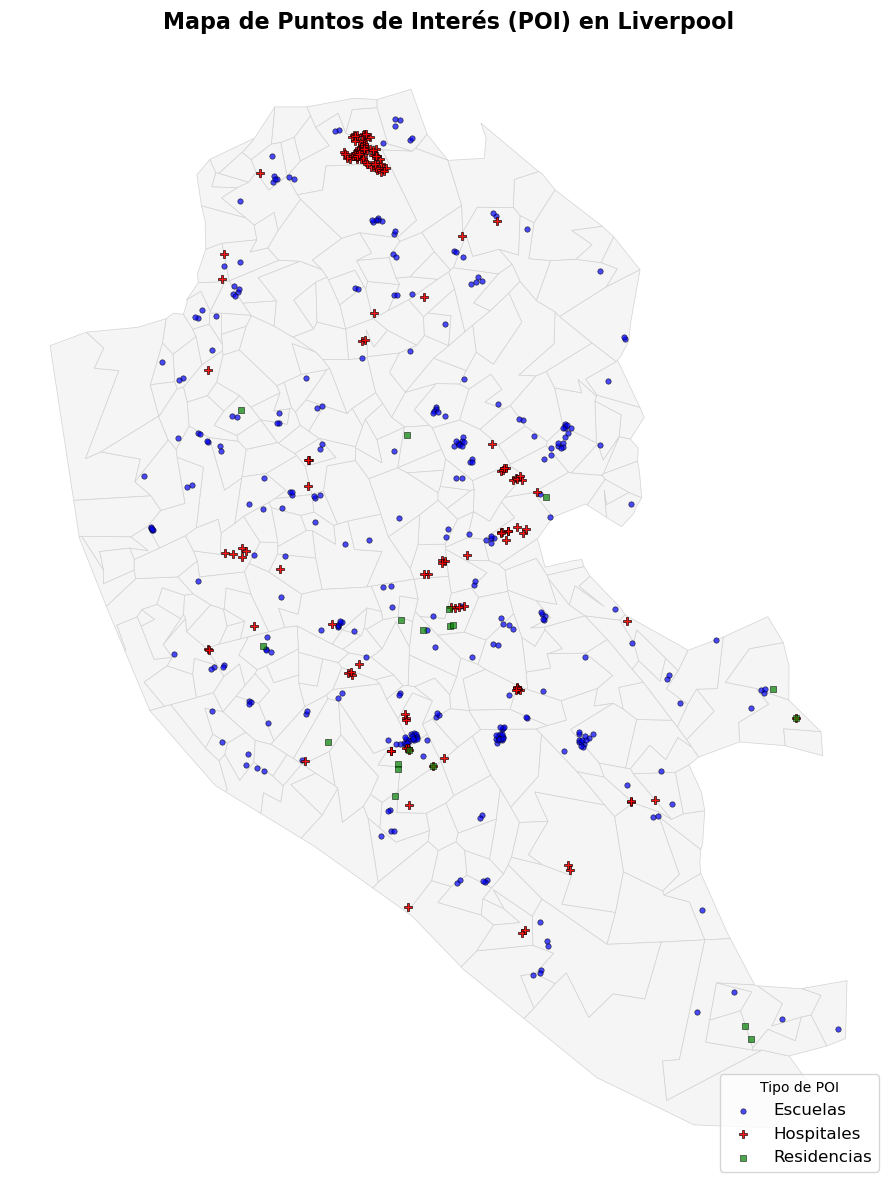

In [ ]:


# 1. Cargar el dataset de edificios (WP3)
buildings = gpd.read_file('../data/raw/buildings_liverpool.gpkg')

# 2. Definir los filtros de OpenStreetMap
buildings['amenity'] = buildings['amenity'].str.lower()
buildings['building'] = buildings['building'].str.lower()

mask_schools = (buildings['amenity'] == 'school') | (buildings['building'] == 'school')
mask_hospitals = (buildings['amenity'] == 'hospital') | (buildings['building'] == 'hospital') | (buildings['amenity'] == 'clinic')
mask_nursing = (buildings['amenity'].isin(['nursing_home', 'social_facility'])) | (buildings['building'] == 'nursing_home')

# 3. Filtrar los DataFrames
schools = buildings[mask_schools].copy()
hospitals = buildings[mask_hospitals].copy()
nursing_homes = buildings[mask_nursing].copy()

#  Igualar los sistemas de coordenadas
schools = schools.to_crs(lsoa_imd.crs)
hospitals = hospitals.to_crs(lsoa_imd.crs)
nursing_homes = nursing_homes.to_crs(lsoa_imd.crs)

# Extraer el centro (punto) de los polígonos
schools['geometry'] = schools.geometry.centroid
hospitals['geometry'] = hospitals.geometry.centroid
nursing_homes['geometry'] = nursing_homes.geometry.centroid

print(f"Encontrados: {len(schools)} Escuelas, {len(hospitals)} Hospitales/Clínicas, {len(nursing_homes)} Residencias.")

# ==========================================
# 4. MAPEO (Visualización)
# ==========================================
fig, ax = plt.subplots(1, 1, figsize=(15, 12))

# Mapa base LSOA
lsoa_imd.plot(ax=ax, color='whitesmoke', edgecolor='lightgrey', linewidth=0.5)

# Puntos POIs
schools.plot(ax=ax, color='blue', marker='o', markersize=15, alpha=0.7, label='Escuelas', edgecolor='black', linewidth=0.5)
hospitals.plot(ax=ax, color='red', marker='P', markersize=40, alpha=0.9, label='Hospitales', edgecolor='black', linewidth=0.5)
nursing_homes.plot(ax=ax, color='green', marker='s', markersize=20, alpha=0.7, label='Residencias', edgecolor='black', linewidth=0.5)

# Títulos y Leyenda
plt.title("Mapa de Puntos de Interés (POI) en Liverpool", fontsize=16, fontweight='bold')
ax.legend(title="Tipo de POI", fontsize=12, loc='lower right')
ax.set_axis_off()

plt.tight_layout()
plt.show()



---
## 3. Análisis de Correlación

ANÁLISIS DE CORRELACIÓN POBREZA-POLUCIÓN (PM 2.5)
🔹 Correlación de Spearman (ideal para Deciles): -0.023 (p-value: 6.916e-01)
🔸 Correlación de Pearson: -0.045 (p-value: 4.406e-01)
--------------------------------------------------
>>> INTERPRETACIÓN: No hay una correlación lineal o monótona muy fuerte evidente.


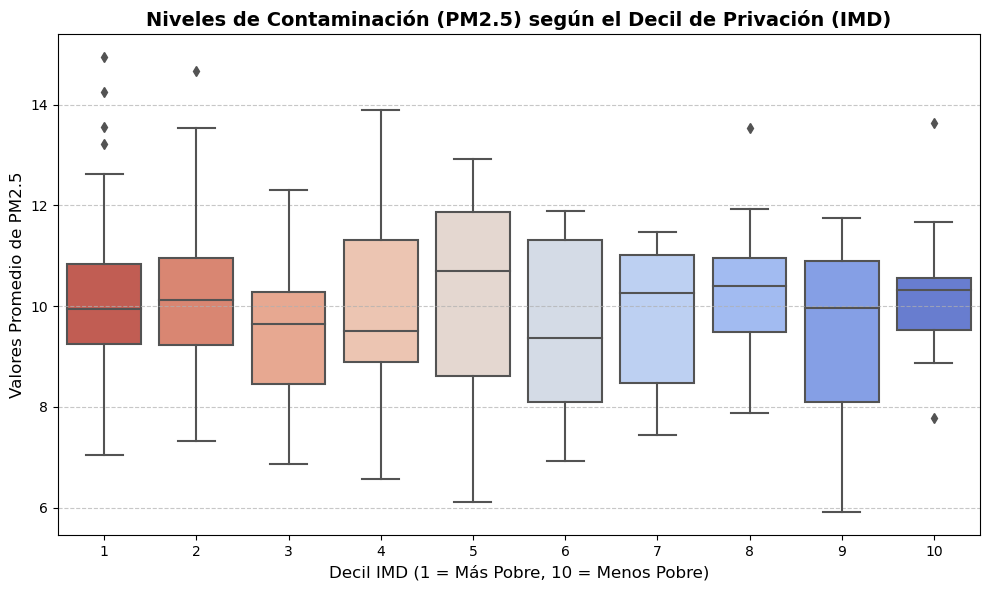

In [4]:


# 1. Limpiamos cualquier barrio que nos haya llegado sin datos para evitar fallos matemáticos
df_stats = df_final.dropna(subset=['Index of Multiple Deprivation (IMD) Decile', 'pm25_pred'])

# Asegurar tipo numérico
x = df_stats['Index of Multiple Deprivation (IMD) Decile']
y = df_stats['pm25_pred']

# 2. Calcular los coeficientes
spearman_corr, spearman_p = spearmanr(x, y)
pearson_corr, pearson_p = pearsonr(x, y)

print("="*50)
print("ANÁLISIS DE CORRELACIÓN POBREZA-POLUCIÓN (PM 2.5)")
print("="*50)
print(f"🔹 Correlación de Spearman (ideal para Deciles): {spearman_corr:.3f} (p-value: {spearman_p:.3e})")
print(f"🔸 Correlación de Pearson: {pearson_corr:.3f} (p-value: {pearson_p:.3e})")
print("-"*50)

# 3. INTERPRETACIÓN AUTOMÁTICA
if spearman_corr < -0.3 and spearman_p < 0.05:
    print(">>> INTERPRETACIÓN: Existe una correlación NEGATIVA SIGNIFICATIVA. ")
    print(">>> Es decir, a MENOR decil de IMD (MÁS pobreza), MAYOR es la contaminación.")
    print(">>> Esto demuestra una clara Desigualdad Ambiental (""Doble Carga"").")
elif spearman_corr > 0.3 and spearman_p < 0.05:
    print(">>> INTERPRETACIÓN: Existe una correlación POSITIVA SIGNIFICATIVA.")
else:
    print(">>> INTERPRETACIÓN: No hay una correlación lineal o monótona muy fuerte evidente.")

# 4. Gráfico Visual con Tendencia (Boxplot y Scatter jointplot)
plt.figure(figsize=(10, 6))

# Usamos Seaborn para un gráfico de cajas (ideal para ver la evolución por deciles)
sns.boxplot(data=df_stats, x='Index of Multiple Deprivation (IMD) Decile', y='pm25_pred', palette='coolwarm_r')


plt.title("Niveles de Contaminación (PM2.5) según el Decil de Privación (IMD)", fontsize=14, fontweight='bold')
plt.xlabel("Decil IMD (1 = Más Pobre, 10 = Menos Pobre)", fontsize=12)
plt.ylabel("Valores Promedio de PM2.5", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


---
## 4. Identificación de "Hotspots de Desigualdad

🔥 HOTSPOTS DE DESIGUALDAD ENCONTRADOS: 38 Barrios (LSOAs)
- Criterio de Pobreza: Deciles 1 o 2.
- Criterio de Polución: Por encima de 10.95 µg/m³ de PM2.5.
------------------------------------------------------------


,LSOA name (2021),Index of Multiple Deprivation (IMD) Decile,pm25_pred
74,Liverpool 017E,1,14.940602
73,Liverpool 017D,2,14.661269
67,Liverpool 017B,1,14.239074
71,Liverpool 025D,1,13.556683
137,Liverpool 013B,2,13.537968
115,Liverpool 011A,2,13.352091
235,Liverpool 040C,2,13.251692
66,Liverpool 017A,1,13.217381
117,Liverpool 016A,2,13.159708
114,Liverpool 010B,2,12.814796


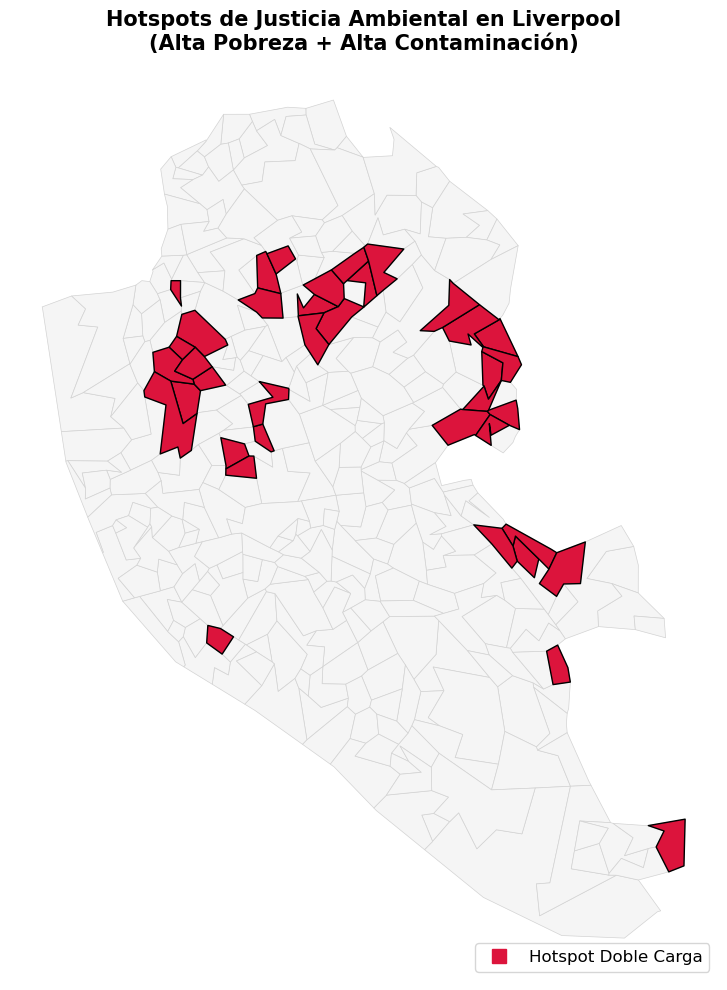

In [5]:


# 1. Definir los umbrales críticos 
# Cogemos los deciles 1 y 2 (El 20% más desfavorecido)
UMBRAL_POBREZA = 2 

# Cogemos el percentil 75 (El 25% más contaminado de todo Liverpool)
UMBRAL_POLUCION = df_final['pm25_pred'].quantile(0.75) 

# 2. Filtrar los Hotspots (DOBLE CARGA)
hotspots = df_final[(df_final['Index of Multiple Deprivation (IMD) Decile'] <= UMBRAL_POBREZA) & 
                    (df_final['pm25_pred'] >= UMBRAL_POLUCION)].copy()

# Ordenar de peor a "menos peor" (mayor polución y menor decil)
hotspots = hotspots.sort_values(by=['pm25_pred'], ascending=False)

print("="*60)
print(f"🔥 HOTSPOTS DE DESIGUALDAD ENCONTRADOS: {len(hotspots)} Barrios (LSOAs)")
print("="*60)
print(f"- Criterio de Pobreza: Deciles 1 o 2.")
print(f"- Criterio de Polución: Por encima de {UMBRAL_POLUCION:.2f} µg/m³ de PM2.5.")
print("-"*60)
# Mostrar el Top 10 crítico como listado limpio
display(hotspots[['LSOA name (2021)', 'Index of Multiple Deprivation (IMD) Decile', 'pm25_pred']].head(10))


# 3. Graficar los Hotspots en el Mapa 
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Dibujar TODOS los barrios en gris clarito como fondo
df_final.plot(ax=ax, color='whitesmoke', edgecolor='lightgrey', linewidth=0.5)

# Dibujar SOLO los Hotspots en ROJO intenso, destacando
hotspots.plot(ax=ax, color='crimson', edgecolor='black', linewidth=1, label="Hotspots Doble Carga")

plt.title('Hotspots de Justicia Ambiental en Liverpool\n(Alta Pobreza + Alta Contaminación)', fontsize=15, fontweight='bold')
ax.set_axis_off()

# Crear una pequeña leyenda personalizada
import matplotlib.lines as mlines
red_patch = mlines.Line2D([], [], color='crimson', marker='s', linestyle='None',
                          markersize=10, label='Hotspot Doble Carga')
ax.legend(handles=[red_patch], loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()


---
## 5. Evaluación de Escuelas (OMS)

⚠️ EVALUACIÓN DE CENTROS EDUCATIVOS: LÍMITE DE POLUCIÓN DE LA OMS
Total de escuelas mapeadas en barrios: 318
Escuelas en zonas con PM2.5 crítico (> 5.0 µg/m³): 318 (100.0%)
---------------------------------------------------------------------------
Top 10 - Entornos escolares más contaminados y su nivel de pobreza:


,name,LSOA name (2021),Index of Multiple Deprivation (IMD) Decile,pm25_pred
23454,NaN,Liverpool 017E,1,14.940602
19430,NaN,Liverpool 017B,1,14.239074
23592,NaN,Liverpool 013D,4,13.888629
23453,NaN,Liverpool 013D,4,13.888629
23488,NaN,Liverpool 047B,10,13.632718
23493,NaN,Liverpool 047B,10,13.632718
23480,NaN,Liverpool 047B,10,13.632718
23492,NaN,Liverpool 047B,10,13.632718
23491,NaN,Liverpool 047B,10,13.632718
23490,NaN,Liverpool 047B,10,13.632718


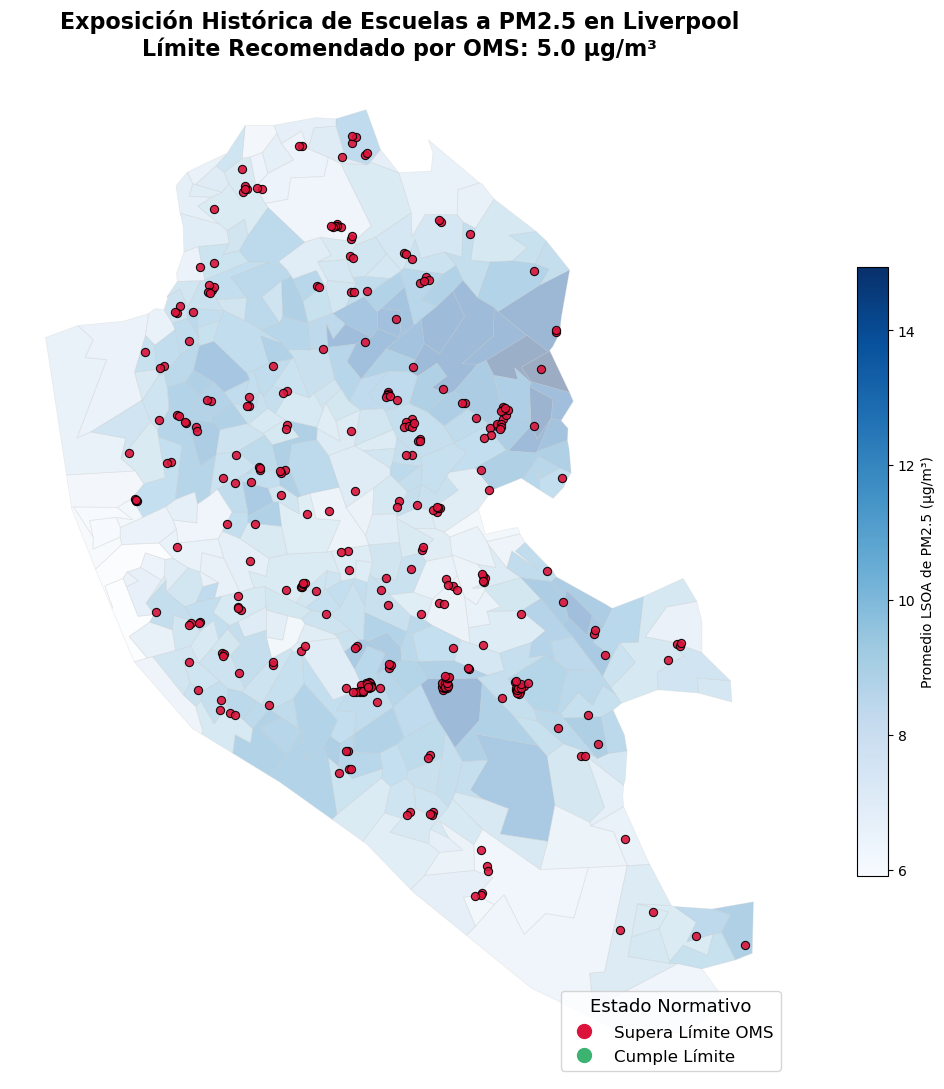

In [6]:

# ==========================================
# 5. EVALUACIÓN DE ESCUELAS FRENTE A LIMITES OMS
# ==========================================


# Límite anual recomendado por la OMS para PM2.5: 5 µg/m³ 
# (Nota: Puedes cambiarlo a 10.0 si prefieres enfocarlo bajo el límite previo a 2021)
LIMITE_OMS_PM25 = 5.0 

# 1. Aseguramos que las geometrías de escuelas compartan coordenadas con nuestro mapa de barrios
schools = schools.to_crs(df_final.crs)

# 2. Filtramos algunas columnas de df_final para que el Join quede más limpio
barrios_polucion = df_final[['LSOA21CD', 'LSOA name (2021)', 'Index of Multiple Deprivation (IMD) Decile', 'pm25_pred', 'geometry']]

# 3. SPATIAL JOIN: Asigna la contaminación del barrio a la escuela dentro de sus fronteras
schools_pollution = gpd.sjoin(schools, barrios_polucion, how="inner", predicate="intersects")

# 4. Impacto: ¿Cuántos colegios superan la línea roja de la OMS?
schools_exceeding = schools_pollution[schools_pollution['pm25_pred'] > LIMITE_OMS_PM25]
schools_safe = schools_pollution[schools_pollution['pm25_pred'] <= LIMITE_OMS_PM25]

# Cálculo de Estadísticas
total_schools = len(schools_pollution)
exceeded_count = len(schools_exceeding)
pct_exceeded = (exceeded_count / total_schools * 100) if total_schools > 0 else 0

# ----- IMPRESIÓN DEL REPORTE -----
print("="*75)
print(f"⚠️ EVALUACIÓN DE CENTROS EDUCATIVOS: LÍMITE DE POLUCIÓN DE LA OMS")
print("="*75)
print(f"Total de escuelas mapeadas en barrios: {total_schools}")
print(f"Escuelas en zonas con PM2.5 crítico (> {LIMITE_OMS_PM25} µg/m³): {exceeded_count} ({pct_exceeded:.1f}%)")
print("-" * 75)

# Búsqueda de columna 'name' (suelen venir en descargas de OSMnx) para montar el Top 10
cols_display = ['LSOA name (2021)', 'Index of Multiple Deprivation (IMD) Decile', 'pm25_pred']
if 'name' in schools_exceeding.columns:
    cols_display.insert(0, 'name')

top_critical_schools = schools_exceeding.sort_values(by='pm25_pred', ascending=False)
print("Top 10 - Entornos escolares más contaminados y su nivel de pobreza:")
display(top_critical_schools[cols_display].head(10))


# ==========================================
# MAPA: VISUALIZACIÓN DE RIESGO ESCOLAR
# ==========================================
fig, ax = plt.subplots(1, 1, figsize=(14, 11))

# Dibujar el nivel local de contaminación (de fondo semitransparente)
df_final.plot(ax=ax, column='pm25_pred', cmap='Blues', alpha=0.4, 
              edgecolor='lightgrey', linewidth=0.5, legend=True,
              legend_kwds={'shrink': 0.6, 'label': 'Promedio LSOA de PM2.5 (µg/m³)'})

# Escuelas que SOBREPASAN el límite (Círculos Rojos)
if not schools_exceeding.empty:
    schools_exceeding.plot(ax=ax, color='crimson', marker='o', markersize=35, 
                           edgecolor='black', linewidth=0.8, alpha=0.9, zorder=5)

# Escuelas que SÍ CUMPLEN el límite (Círculos Verdes - Si hay alguna)
if not schools_safe.empty:
    schools_safe.plot(ax=ax, color='mediumseagreen', marker='o', markersize=35, 
                      edgecolor='black', linewidth=0.8, alpha=0.9, zorder=5)

# Configuración del gráfico
plt.title(f"Exposición Histórica de Escuelas a PM2.5 en Liverpool\nLímite Recomendado por OMS: {LIMITE_OMS_PM25} µg/m³", 
          fontsize=16, fontweight='bold')
ax.set_axis_off()

# Leyenda customizada para los puntos
etiquetas_leyenda = [
    mlines.Line2D([], [], color='crimson', marker='o', linestyle='None', markersize=10, label='Supera Límite OMS'),
    mlines.Line2D([], [], color='mediumseagreen', marker='o', linestyle='None', markersize=10, label='Cumple Límite')
]
ax.legend(handles=etiquetas_leyenda, loc='lower right', title='Estado Normativo', fontsize=12, title_fontsize=13)

plt.tight_layout()
plt.show()


Este es uno de los grandes problemas ambientales a nivel global en la actualidad

La realidad de Liverpool: El nivel más bajo de PM2.5 registrado en nuestro mapa para cualquier barrio de Liverpool es de $5.9\ \mu g/m^3$ y la media está en $10.0\ \mu g/m^3$.
La estricta directiz de la OMS (2021) que es el límite que estamos utilizando es de ($5.0\ \mu g/m^3$),la cual es la recomendación más reciente y estricta de la OMS. Según informes recientes, aproximadamente el 97% de las zonas urbanas de Europa superan este límite actual. Las ciudades del Reino Unido, especialmente las industriales como Liverpool, no son una excepción.
Por lo tanto, dado que no hay ningún barrio en Liverpool que baje de $5.9$, es matemáticamente imposible que una escuela que esté dentro de Liverpool baje de $5.0$.




---
## 5. Evaluación de Escuelas (Europa)

En consecuencia, en vez de compararlo con el límite de la OMS,vamos a compararlo con la media europea de niveles de contaminacion PM2.5, que es de $11.2\ \mu g/m^3$

⚠️ EVALUACIÓN DE CENTROS EDUCATIVOS: MEDIA DE POLUCIÓN EN EUROPA
Total de escuelas mapeadas en barrios: 318
Escuelas en zonas por encima de la media de Europa (> 11.2 µg/m³): 76 (23.9%)
---------------------------------------------------------------------------
Top 10 - Entornos escolares más alejados de la media de Europa y su nivel de pobreza:


,name,LSOA name (2021),Index of Multiple Deprivation (IMD) Decile,pm25_pred
23454,NaN,Liverpool 017E,1,14.940602
19430,NaN,Liverpool 017B,1,14.239074
23453,NaN,Liverpool 013D,4,13.888629
23592,NaN,Liverpool 013D,4,13.888629
23483,NaN,Liverpool 047B,10,13.632718
23492,NaN,Liverpool 047B,10,13.632718
23491,NaN,Liverpool 047B,10,13.632718
23490,NaN,Liverpool 047B,10,13.632718
23489,NaN,Liverpool 047B,10,13.632718
23488,NaN,Liverpool 047B,10,13.632718


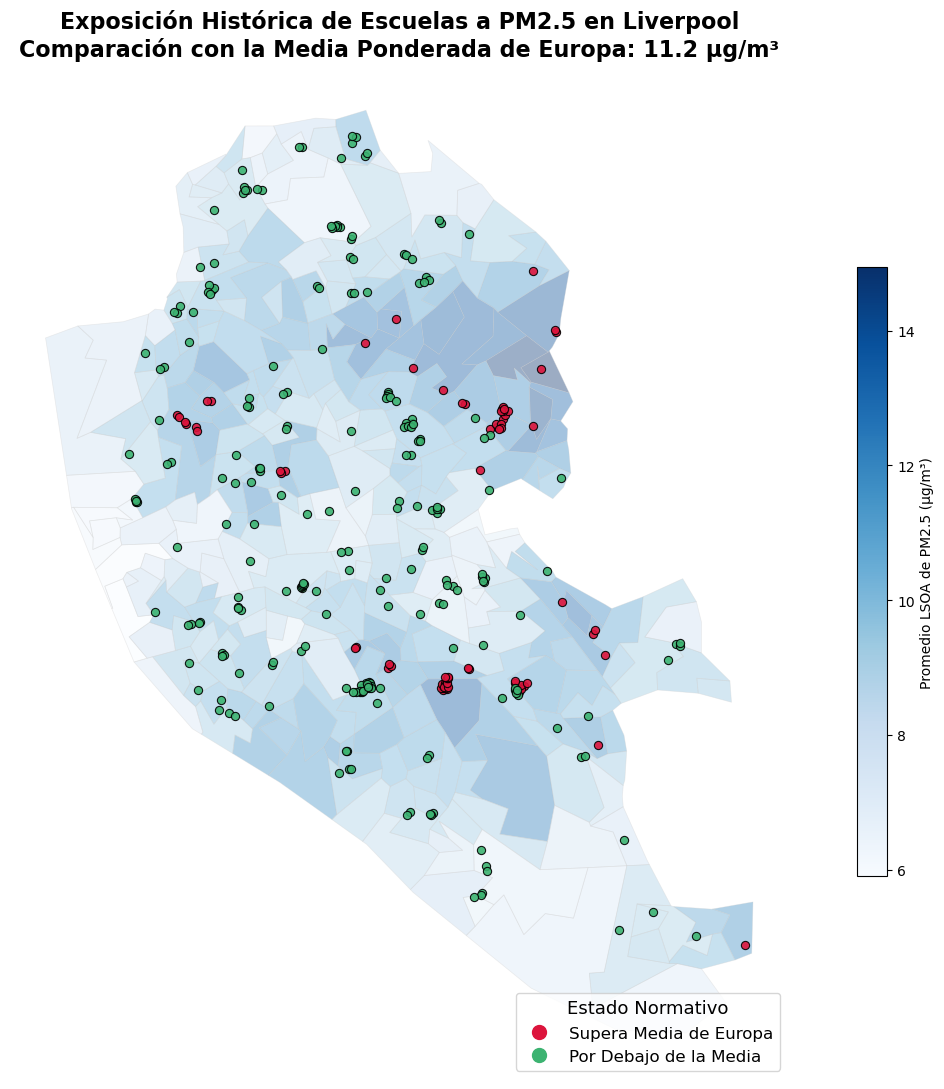

In [7]:
# ==========================================
# 5.b EVALUACIÓN DE ESCUELAS FRENTE A MEDIA DE EUROPA
# ==========================================

MEDIA_EUROPA_PM25 = 11.2 

# 1. Aseguramos que las geometrías de escuelas compartan coordenadas con nuestro mapa de barrios
schools = schools.to_crs(df_final.crs)

# 2. Filtramos algunas columnas de df_final para que el Join quede más limpio
barrios_polucion = df_final[['LSOA21CD', 'LSOA name (2021)', 'Index of Multiple Deprivation (IMD) Decile', 'pm25_pred', 'geometry']]

# 3. SPATIAL JOIN: Asigna la contaminación del barrio a la escuela dentro de sus fronteras
schools_pollution = gpd.sjoin(schools, barrios_polucion, how="inner", predicate="intersects")

# 4. Impacto: ¿Cuántos colegios superan la media de Europa?
schools_exceeding_eu = schools_pollution[schools_pollution['pm25_pred'] > MEDIA_EUROPA_PM25]
schools_safe_eu = schools_pollution[schools_pollution['pm25_pred'] <= MEDIA_EUROPA_PM25]

# Cálculo de Estadísticas
total_schools = len(schools_pollution)
exceeded_count_eu = len(schools_exceeding_eu)
pct_exceeded_eu = (exceeded_count_eu / total_schools * 100) if total_schools > 0 else 0

# ----- IMPRESIÓN DEL REPORTE -----
print("="*75)
print(f"⚠️ EVALUACIÓN DE CENTROS EDUCATIVOS: MEDIA DE POLUCIÓN EN EUROPA")
print("="*75)
print(f"Total de escuelas mapeadas en barrios: {total_schools}")
print(f"Escuelas en zonas por encima de la media de Europa (> {MEDIA_EUROPA_PM25} µg/m³): {exceeded_count_eu} ({pct_exceeded_eu:.1f}%)")
print("-" * 75)

# Búsqueda de columna 'name' (suelen venir en descargas de OSMnx) para montar el Top 10
cols_display = ['LSOA name (2021)', 'Index of Multiple Deprivation (IMD) Decile', 'pm25_pred']
if 'name' in schools_exceeding_eu.columns:
    cols_display.insert(0, 'name')

top_critical_schools_eu = schools_exceeding_eu.sort_values(by='pm25_pred', ascending=False)
print("Top 10 - Entornos escolares más alejados de la media de Europa y su nivel de pobreza:")
display(top_critical_schools_eu[cols_display].head(10))


# ==========================================
# MAPA: VISUALIZACIÓN FRENTE A MEDIA EUROPEA
# ==========================================
fig, ax = plt.subplots(1, 1, figsize=(14, 11))

# Dibujar el nivel local de contaminación (de fondo semitransparente)
df_final.plot(ax=ax, column='pm25_pred', cmap='Blues', alpha=0.4, 
              edgecolor='lightgrey', linewidth=0.5, legend=True,
              legend_kwds={'shrink': 0.6, 'label': 'Promedio LSOA de PM2.5 (µg/m³)'})

# Escuelas que SOBREPASAN la media (Círculos Rojos)
if not schools_exceeding_eu.empty:
    schools_exceeding_eu.plot(ax=ax, color='crimson', marker='o', markersize=35, 
                           edgecolor='black', linewidth=0.8, alpha=0.9, zorder=5)

# Escuelas que SÍ CUMPLEN o están por debajo de la media (Círculos Verdes)
if not schools_safe_eu.empty:
    schools_safe_eu.plot(ax=ax, color='mediumseagreen', marker='o', markersize=35, 
                      edgecolor='black', linewidth=0.8, alpha=0.9, zorder=5)

# Configuración del gráfico
plt.title(f"Exposición Histórica de Escuelas a PM2.5 en Liverpool\nComparación con la Media Ponderada de Europa: {MEDIA_EUROPA_PM25} µg/m³", 
          fontsize=16, fontweight='bold')
ax.set_axis_off()

# Leyenda customizada para los puntos
etiquetas_leyenda = [
    mlines.Line2D([], [], color='crimson', marker='o', linestyle='None', markersize=10, label='Supera Media de Europa'),
    mlines.Line2D([], [], color='mediumseagreen', marker='o', linestyle='None', markersize=10, label='Por Debajo de la Media')
]
ax.legend(handles=etiquetas_leyenda, loc='lower right', title='Estado Normativo', fontsize=12, title_fontsize=13)

plt.tight_layout()
plt.show()


---
## 6. Informe de vulnerabilidad

Como ya hemos explicado antes, el límite recomendado por la OMS en PM2.5 es de $5\ \mu g/m^3$ , pero usamos la media de europa para que no salga el 100% de los resultados

In [8]:
# ====================================================================
# 6. INFORME DE VULNERABILIDAD: NIÑOS Y ANCIANOS FRENTE A LÍMITE
# ====================================================================

LIMITE_LEGAL_PM25 = 11.2

# 1. Asegurar la proyección de residencias de ancianos
nursing_homes = nursing_homes.to_crs(df_final.crs)

# 2. Realizar el Spatial Join para asignar la contaminación a las residencias (ancianos)
nursing_homes_pollution = gpd.sjoin(nursing_homes, barrios_polucion, how="inner", predicate="intersects")

# 3. Filtrar cuáles superan el límite (usamos schools_pollution que ya tienes calculado)
schools_exceeding_legal = schools_pollution[schools_pollution['pm25_pred'] > LIMITE_LEGAL_PM25]
nursing_exceeding_legal = nursing_homes_pollution[nursing_homes_pollution['pm25_pred'] > LIMITE_LEGAL_PM25]

# 4. Estadísticas Población Vulnerable (Niños -> Escuelas; Ancianos -> Residencias)
total_schools = len(schools_pollution)
exceeded_schools = len(schools_exceeding_legal)
pct_schools = (exceeded_schools / total_schools * 100) if total_schools > 0 else 0

total_nursing = len(nursing_homes_pollution)
exceeded_nursing = len(nursing_exceeding_legal)
pct_nursing = (exceeded_nursing / total_nursing * 100) if total_nursing > 0 else 0

# 5. Cálculo Combinado
total_vulnerable_pois = total_schools + total_nursing
exceeded_vulnerable_pois = exceeded_schools + exceeded_nursing
pct_vulnerable = (exceeded_vulnerable_pois / total_vulnerable_pois * 100) if total_vulnerable_pois > 0 else 0

# ----- IMPRESIÓN DEL REPORTE -----
print("="*75)
print(f"⚠️ INFORME DE VULNERABILIDAD: EXPOSICIÓN A PM2.5 (> {LIMITE_LEGAL_PM25} µg/m³)")
print("="*75)
print(f"POBLACIÓN INFANTIL (Escuelas):")
print(f" - Contabilizadas: {total_schools}")
print(f" - En zona de riesgo legal: {exceeded_schools} ({pct_schools:.1f}%)")
print("-" * 75)
print(f"POBLACIÓN MAYOR (Residencias de Ancianos):")
print(f" - Contabilizadas: {total_nursing}")
print(f" - En zona de riesgo legal: {exceeded_nursing} ({pct_nursing:.1f}%)")
print("="*75)
print(f"📉 RESUMEN COMBINADO DE VULNERABILIDAD:")
print(f" -> El {pct_vulnerable:.1f}% de los espacios destinados a población vulnerable (niños/ancianos)")
print(f"    se encuentra recluido en zonas geográficas que superan los {LIMITE_LEGAL_PM25} µg/m³.")
print("="*75)


⚠️ INFORME DE VULNERABILIDAD: EXPOSICIÓN A PM2.5 (> 11.2 µg/m³)
POBLACIÓN INFANTIL (Escuelas):
 - Contabilizadas: 318
 - En zona de riesgo legal: 76 (23.9%)
---------------------------------------------------------------------------
POBLACIÓN MAYOR (Residencias de Ancianos):
 - Contabilizadas: 19
 - En zona de riesgo legal: 2 (10.5%)
📉 RESUMEN COMBINADO DE VULNERABILIDAD:
 -> El 23.1% de los espacios destinados a población vulnerable (niños/ancianos)
    se encuentra recluido en zonas geográficas que superan los 11.2 µg/m³.
